In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from collections import Counter
import random
import matplotlib.pyplot as plt



# Load dataset

In [4]:
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names



# Class indices


In [5]:
class_0 = np.where(y == 0)[0]
class_1 = np.where(y == 1)[0]
class_2 = np.where(y == 2)[0]

bags = 5
bag_predictions = []


========== BAG 1 ==========
Tree 1 → Features: ['petal width (cm)', 'petal length (cm)']


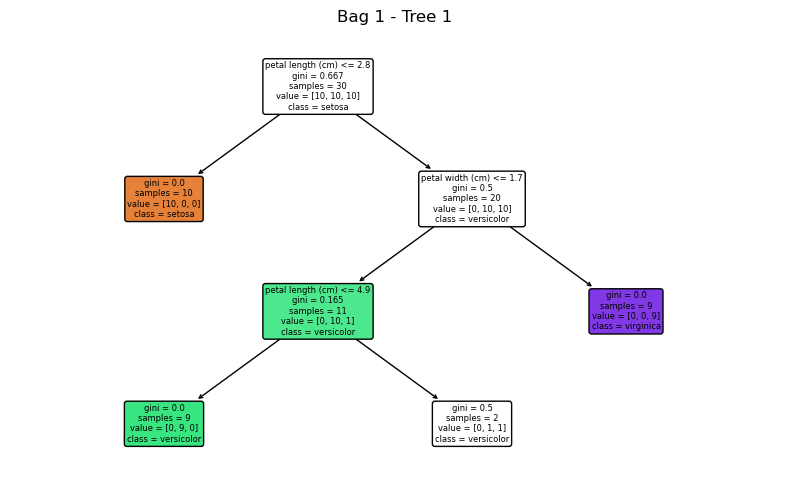

Tree 2 → Features: ['petal width (cm)', 'sepal length (cm)']


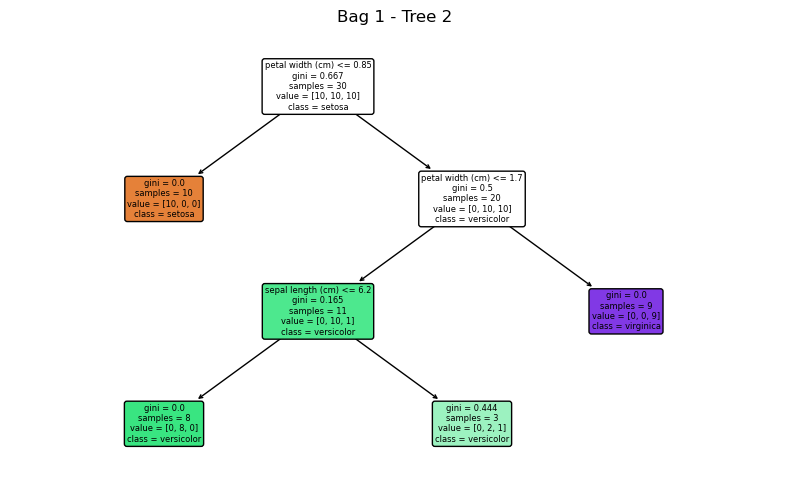

Tree 3 → Features: ['petal width (cm)', 'sepal width (cm)']


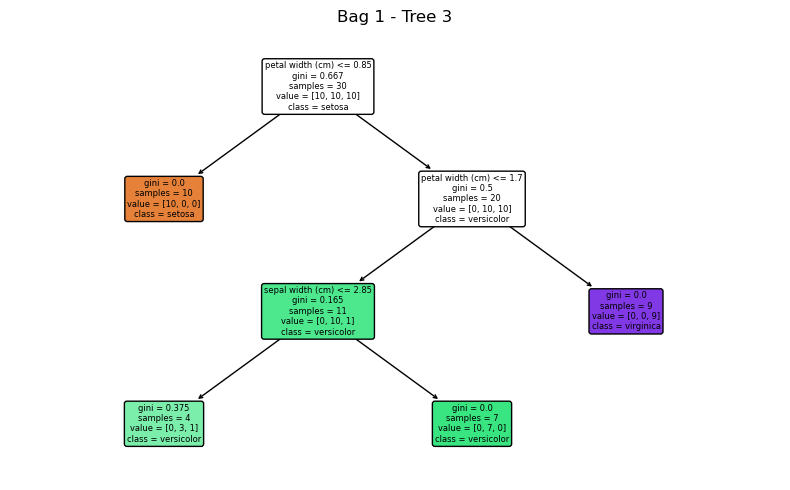

✅ Bag 1 Accuracy: 96.00%

========== BAG 2 ==========
Tree 1 → Features: ['petal length (cm)', 'petal width (cm)']


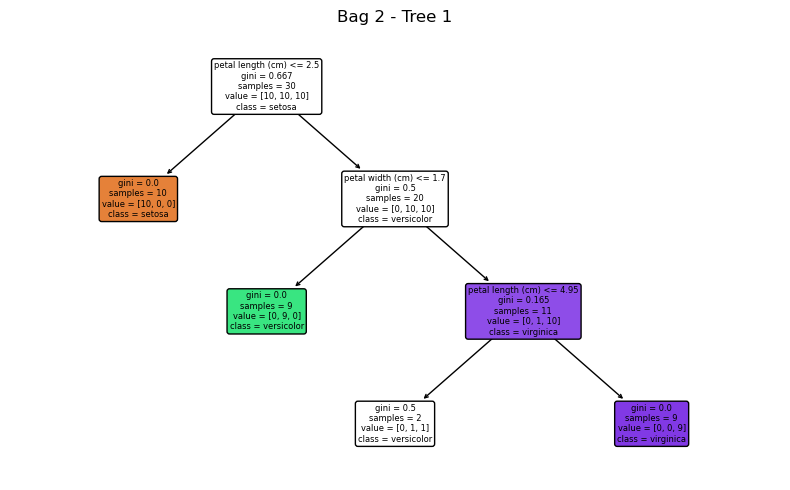

Tree 2 → Features: ['petal length (cm)', 'petal width (cm)']


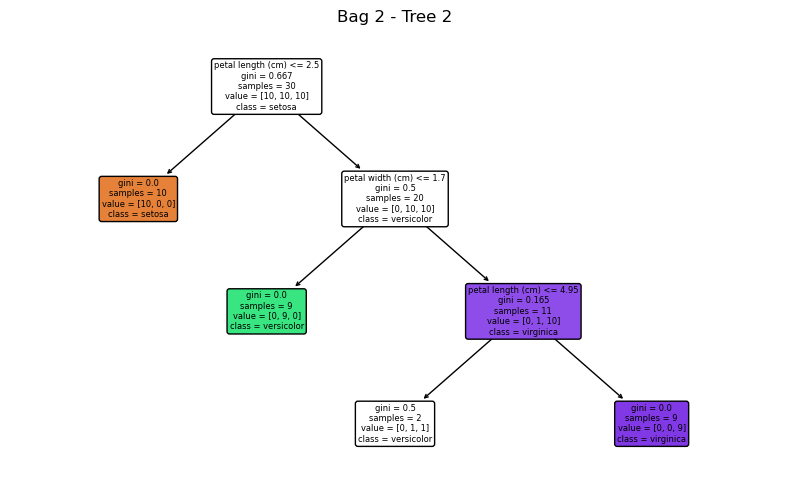

Tree 3 → Features: ['sepal length (cm)', 'petal width (cm)']


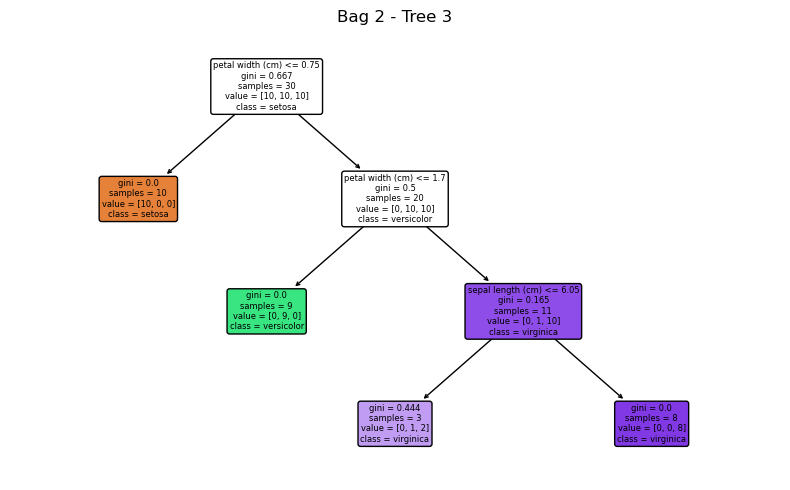

✅ Bag 2 Accuracy: 92.67%

========== BAG 3 ==========
Tree 1 → Features: ['sepal width (cm)', 'petal width (cm)']


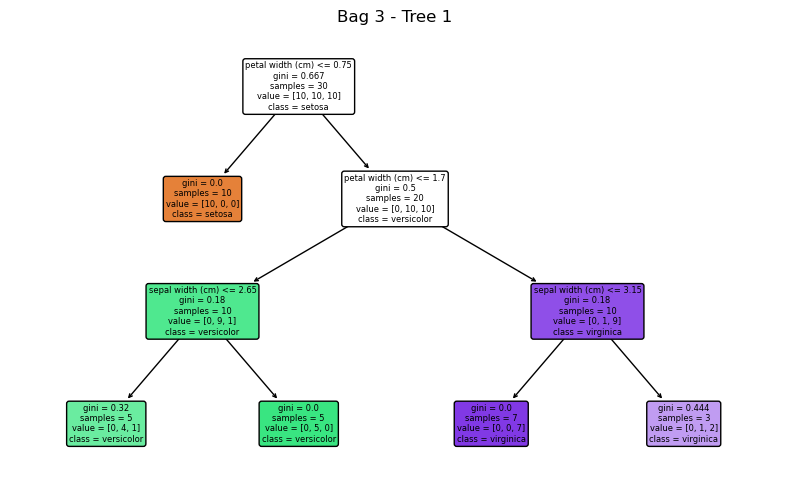

Tree 2 → Features: ['petal width (cm)', 'sepal width (cm)']


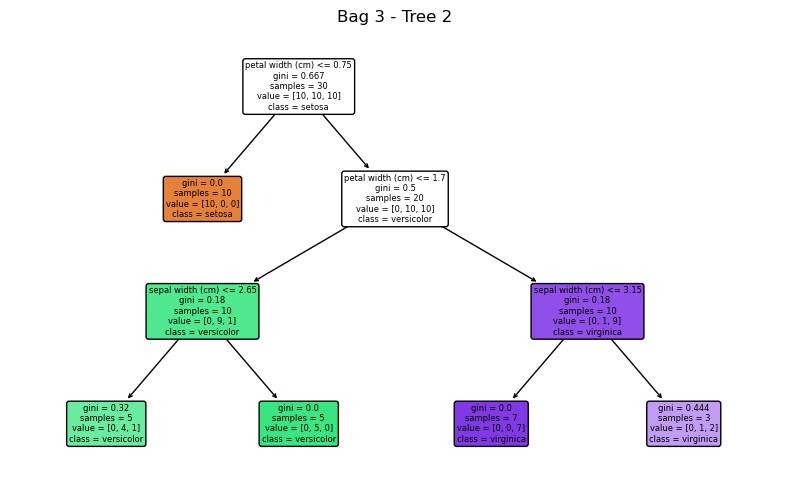

Tree 3 → Features: ['sepal width (cm)', 'sepal length (cm)']


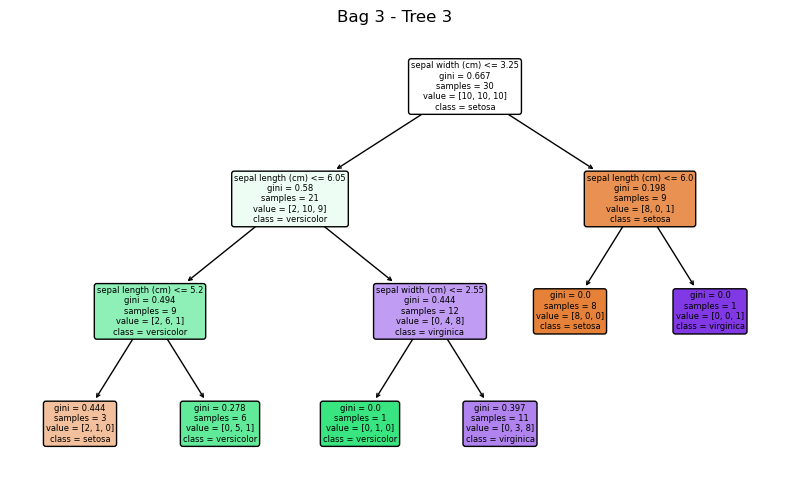

✅ Bag 3 Accuracy: 96.00%

========== BAG 4 ==========
Tree 1 → Features: ['petal width (cm)', 'petal length (cm)']


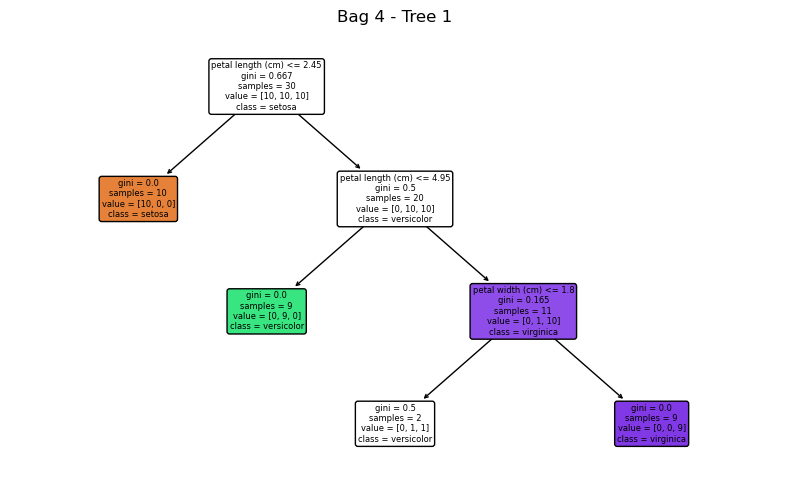

Tree 2 → Features: ['sepal width (cm)', 'petal width (cm)']


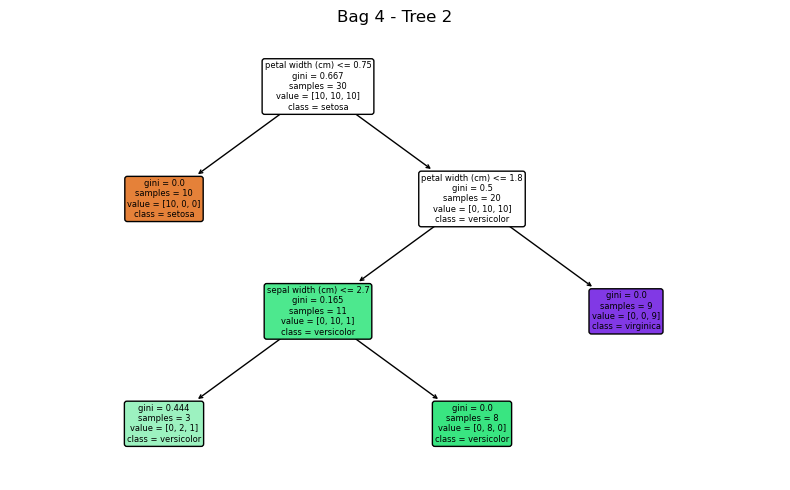

Tree 3 → Features: ['petal length (cm)', 'petal width (cm)']


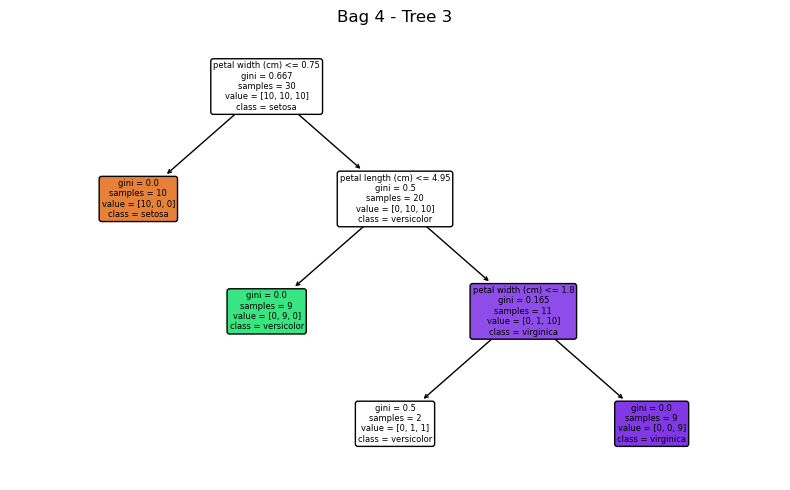

✅ Bag 4 Accuracy: 88.67%

========== BAG 5 ==========
Tree 1 → Features: ['sepal length (cm)', 'petal width (cm)']


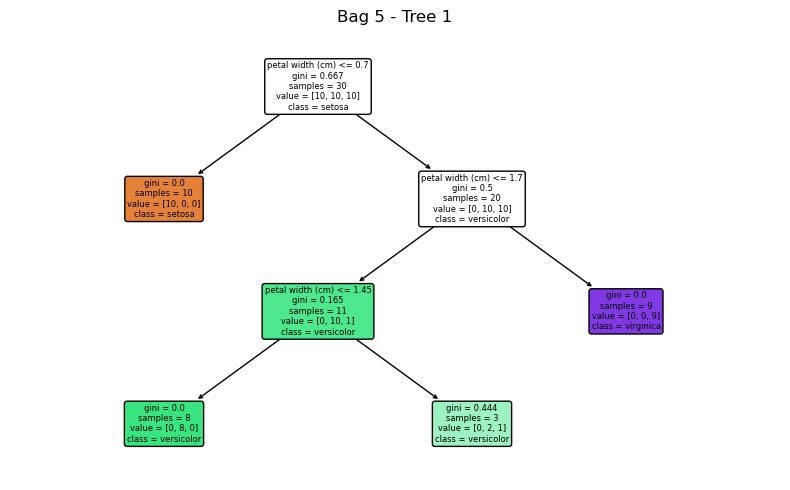

Tree 2 → Features: ['petal width (cm)', 'sepal width (cm)']


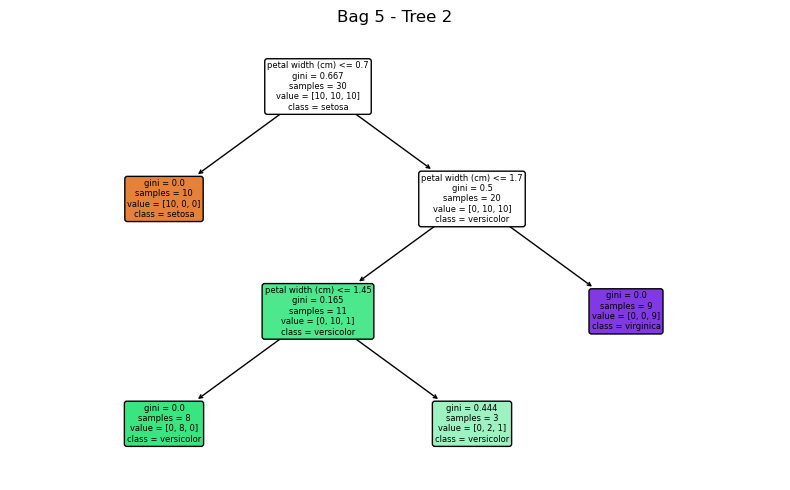

Tree 3 → Features: ['sepal length (cm)', 'petal width (cm)']


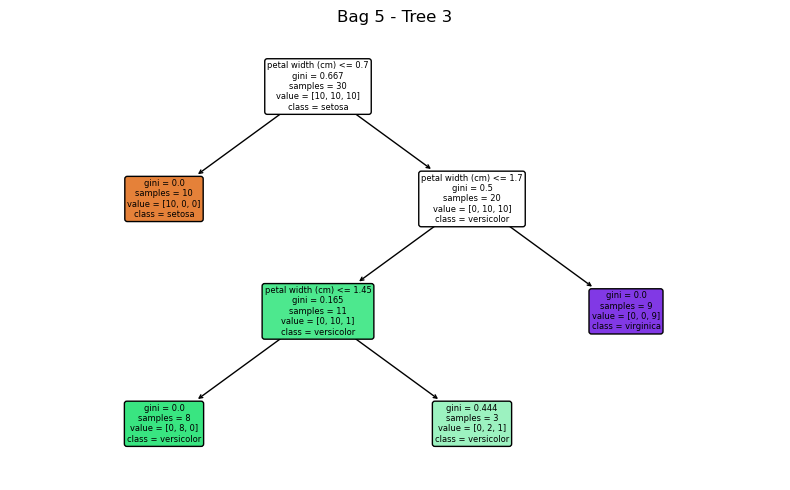

✅ Bag 5 Accuracy: 96.00%


In [10]:
for b in range(bags):
    indices = []

    # 10 samples per class
    indices.extend(np.random.choice(class_0, 10, replace=False))
    indices.extend(np.random.choice(class_1, 10, replace=False))
    indices.extend(np.random.choice(class_2, 10, replace=False))

    indices = np.array(indices)
    trees = []

    print(f"\n========== BAG {b+1} ==========")

    # 🔹 3 Decision Trees per bag
    for t in range(3):
        features = random.sample(range(4), 2)

        X_subset = X[indices][:, features]
        y_subset = y[indices]

        model = DecisionTreeClassifier(max_depth=3)
        model.fit(X_subset, y_subset)

        trees.append((model, features))

        print(f"Tree {t+1} → Features: {[feature_names[f] for f in features]}")

        # 🔹 Neat plot
        plt.figure(figsize=(8, 5))
        plot_tree(model,
                  feature_names=[feature_names[f] for f in features],
                  class_names=class_names,
                  filled=True,
                  rounded=True,
                  fontsize=6)
        plt.title(f"Bag {b+1} - Tree {t+1}")
        plt.tight_layout()
        plt.show()

    # 🔹 Prediction for this bag
    bag_pred = []

    for i in range(len(X)):
        votes = []

        for model, features in trees:
            pred = model.predict(X[i][features].reshape(1, -1))[0]
            votes.append(pred)

        final_vote = Counter(votes).most_common(1)[0][0]
        bag_pred.append(final_vote)

    bag_predictions.append(bag_pred)

    # 🔹 Accuracy per bag
    correct = sum(1 for i in range(len(y)) if y[i] == bag_pred[i])
    acc = correct / len(y)

    print(f"✅ Bag {b+1} Accuracy: {acc*100:.2f}%")



In [11]:
# 🔹 Final ensemble prediction
final_predictions = []

for i in range(len(X)):
    votes = [bag_predictions[b][i] for b in range(bags)]
    final_vote = Counter(votes).most_common(1)[0][0]
    final_predictions.append(final_vote)
    
print(f"\n🔥 Final Model Prediction:{final_vote}")
# 🔹 Final accuracy
correct = sum(1 for i in range(len(y)) if y[i] == final_predictions[i])
final_acc = correct / len(y)

print(f"\n🔥 Final Model Accuracy: {final_acc*100:.2f}%")


🔥 Final Model Prediction:2

🔥 Final Model Accuracy: 96.00%
